# Notebook with plots for paper _Virtual Distillation for bosonic systems_

This notebook is used to produce part of the plots appearing in the final version of the paper. It relies on the auxiliary functions from the file ```paper_functions.py```.

In [1]:
import qutip
import numpy as np
import math
import matplotlib.pyplot as plt
#import matplotlib.colors as colors
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from paper_functions import *

colors= [ #color blind friendly list
    "#F5B34C",  # orange
    "#E986DF",  # pinkish
    "#021373", #darkblue
    "#C22C1E",  # red
    "#009B9E",  # teal
    "#7f7f7f",  # gray
    "#4ADA75",  # green 
    "#F5D596", #lightorange
    "#935EEB",  # purple
    "#F23064",  # sete pink
    "#F58C56", #brick orange
    ]    

## I. Theoretical results for number operator

We start by considering three kinds of ideal states: Fock state $\ket3$, binomial state $\frac{1}{\sqrt{2}}(\ket{0} + \ket{4})$, and cat state $\propto \ket{\alpha} + \ket{-\alpha}$.

We let each ideal state evolve through a loss channel for different times, to get our input states for the virtual distillation protocol. We then compute the expectation value for the number operator $\hat n$ and compare the results of no-VD, 2-mode VD, 3-mode VD and 4-mode VD.

In [2]:
### Numerical parameters ###

N = 20 # Hilbert space dimension of one bosonic mode (truncated at N-1 excitations)

T_1 = 500 # μs
decay_rate = 1/T_1 # decay rate κ of the cavity (only for losses)

t_max = 100 # μs (such that κt ~ 0.2)
nb_samples = 40
t_list = np.linspace(0,t_max,nb_samples)

In [3]:
rho_fock_pure = qutip.fock_dm(N, 3)
rho_binomial_pure = qutip.ket2dm((qutip.fock(N,0) + qutip.fock(N,4)).unit())
alpha = 1.0
rho_cat_pure = qutip.ket2dm((qutip.coherent(N, alpha) + qutip.coherent(N, -alpha)).unit())

rho_pure_list = [ (rho_fock_pure, 'Fock state $|3⟩$'), (rho_binomial_pure, 'Binomial state'), (rho_cat_pure, 'Cat state') ]

loss_channel_list = [loss_channel(N, decay_rate, t) for t in t_list]

rho_noisy_list = [ ([channel(rho) for channel in loss_channel_list], label) for (rho, label) in rho_pure_list]


observable = qutip.num(N)
observable_label = '$\\langle\\hat{n}\\rangle$'
M_list = [(1, 'no distillation')] + [(M, f'${M}$-mode VD') for M in [2,3,4]]

def perform_protocol(N, rho_noisy_list, M_list, observable):
    ''' Perform the virtual distillation protocol 
    Input:
        N: Hilbert space dimension of one bosonic mode (truncated at N-1 excitations)
        rho_noisy_list: list of tuples (rho_noisy, label)
        M_list: list of tuples (M, label)
    Output:
        results: array of shape (len(rho_noisy_list), len(M_list), len'''

    results = np.zeros((len(rho_noisy_list), len(M_list), len(rho_noisy_list[0][0])), dtype='complex')
    for i, (rho_noisy, _) in enumerate(rho_noisy_list):
        for j, (M, _) in enumerate(M_list):
            for k, rho in enumerate(rho_noisy):
                results[i,j,k] = virtual_distillation_expectation_value(N, rho, observable, M)
    return results

results = np.real_if_close(perform_protocol(N, rho_noisy_list, M_list, observable))

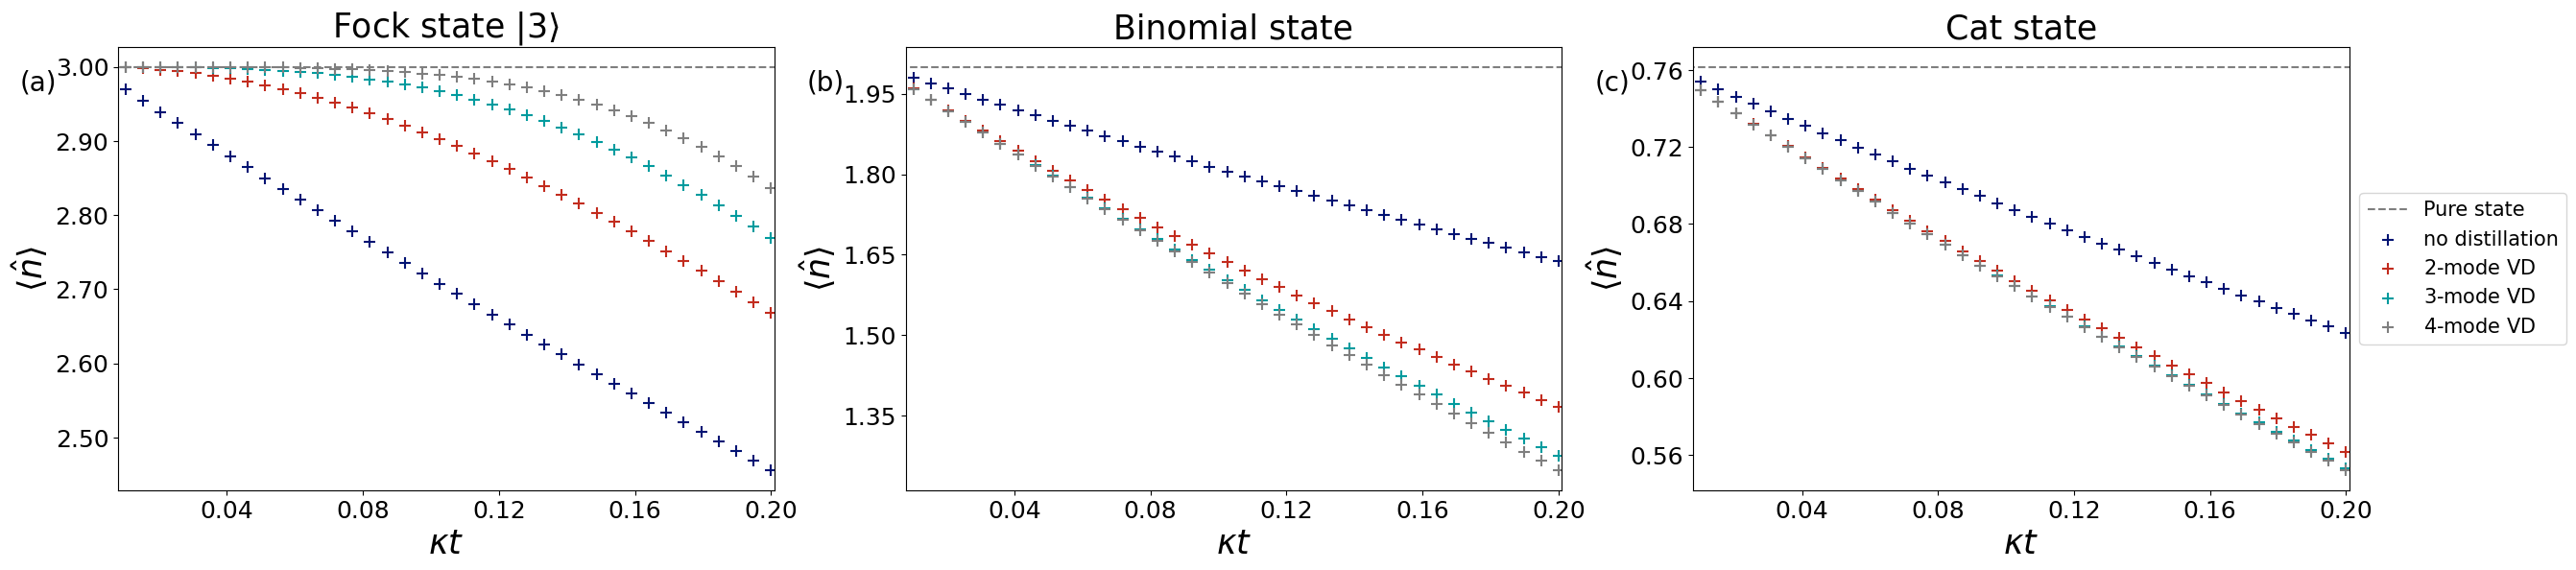

In [4]:
fig, ax = plt.subplots(1, results.shape[0], figsize=(10*results.shape[0],6))
plot_theoretical_results(fig, ax, results, rho_noisy_list, M_list, t_list, observable_label, (decay_rate, "kappa"),
            plot_params = {'colors': colors,
                            'show_wigner': False, 
                           'legend_loc': 'outside right',
                           'xmin': 0.008, 'xmax': 0.201,
                            'tick_list' : [], 'tick_params':None,
                            'labels': ['(a)', '(b)', '(c)'],
                            'wigner_cmap': 'RdBu_r',
                            'wigner_vmax': None})
plt.savefig('plots/Fock_Binom_cat.pdf', bbox_inches='tight')
plt.show()

## II. Parity operator on even, tri and square cat


In [5]:
alpha = 1.50
rho_even_pure = qutip.ket2dm((qutip.coherent(N, alpha) + qutip.coherent(N, -alpha)).unit())
rho_tri_pure = qutip.ket2dm((qutip.coherent(N, alpha) + qutip.coherent(N, alpha*np.exp(2j*np.pi/3)) + qutip.coherent(N, alpha*np.exp(4j*np.pi/3))).unit())
rho_square_pure = qutip.ket2dm((qutip.coherent(N, alpha) + qutip.coherent(N, alpha*1j) + qutip.coherent(N, -alpha) + qutip.coherent(N, -alpha*1j)).unit())

rho_pure_list = [ (rho_even_pure, "Even cat state"), (rho_tri_pure, "Tri cat state"), (rho_square_pure, "Square cat state") ]

rho_noisy_list = [ ([channel(rho) for channel in loss_channel_list], label) for (rho, label) in rho_pure_list]

observable = (1j*np.pi*qutip.num(N)).expm() # Parity operator
observable_label = '$\\langle e^{i\\pi\\hat{n}}\\rangle$'
M_list = [(1, 'no distillation')] + [(M, f'${M}$-mode VD') for M in [2,3,4]]

# results = np.zeros((len(rho_noisy_list), len(M_list), len(t_list)))
# for i, (rho_noisy, _) in enumerate(rho_noisy_list):
#     for j, (M, _) in enumerate(M_list):
#         for k, rho in enumerate(rho_noisy):
#             results[i,j,k] = np.real_if_close(virtual_distillation_expectation_value(N, rho, observable, M))

results = np.real_if_close(perform_protocol(N, rho_noisy_list, M_list, observable))

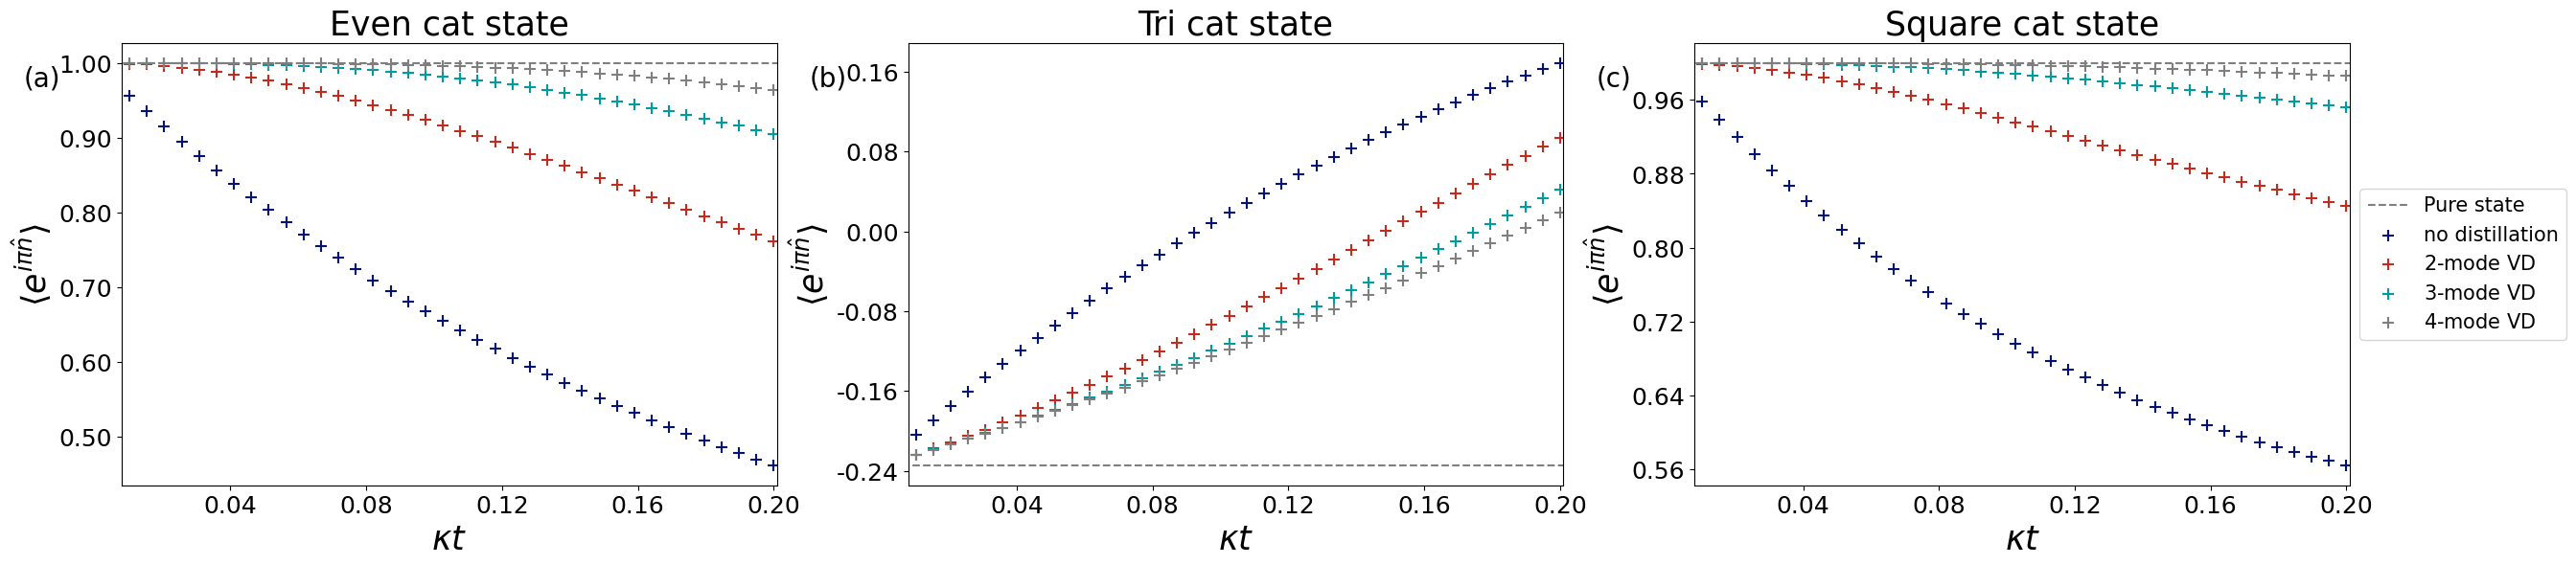

In [6]:
fig, ax = plt.subplots(1, results.shape[0], figsize=(10*results.shape[0],6))
plot_theoretical_results(fig, ax, results, rho_noisy_list, M_list, t_list, observable_label, (decay_rate, "kappa"),
            plot_params = { 'colors': colors,
                            'show_wigner': False, 
                           'legend_loc': 'outside right',
                           'xmin': 0.008, 'xmax': 0.201,
                            'tick_list' : [], 'tick_params':None,
                            'labels': ['(a)', '(b)', '(c)'],
                            'wigner_cmap': 'RdBu_r',
                            'wigner_vmax': None,
                            'idx_wigner_colorbar': 0
                            })

plt.savefig('plots/even_tri_square.pdf', bbox_inches='tight')
plt.show()

## III. Theoretical results for quadrature operator

We measure the two quadrature operators $\hat q$ and $\hat p$, on squeezed coherent states with dephasing noise.

In [7]:
### Numerical parameters ###

N = 20 # Hilbert space dimension of one bosonic mode (truncated at N-1 excitations)

T_2 = 600 # μs
dephasing_rate = 1/T_2 # dephasing rate γ of the cavity

t_max = 200 # μs (such that γt ~ 0.33)
nb_samples = 40
t_list = np.linspace(0,t_max,nb_samples)

In [8]:
alpha = 0.3 + 0.3j
rho_1_pure = qutip.ket2dm(qutip.squeeze(N, 0.5) * qutip.coherent(N, alpha)) # squeezed with 0.5 in q
rho_2_pure = qutip.ket2dm(qutip.squeeze(N, -0.5)*qutip.coherent(N, alpha)) #squeezed with -0.5 in q (i.e. 0.5 in p)

rho_pure_list = [ (rho_1_pure, '$q$-squeezed'), (rho_2_pure, '$p$-squeezed') ]



dephasing_channel_list = [dephasing_channel(N, dephasing_rate, t) for t in t_list]

rho_noisy_list = [ ([channel(rho) for channel in dephasing_channel_list], label) for (rho, label) in rho_pure_list]

observable_q = (qutip.destroy(N) + qutip.create(N)) / np.sqrt(2) # quadrature operator q
observable_q_label = '$\\langle\\hat{q}\\rangle$'

observable_p = (qutip.destroy(N) - qutip.create(N)) / (1j * np.sqrt(2)) # quadrature operator p
observable_p_label = '$\\langle\\hat{p}\\rangle$'

M_list = [(1, 'no distillation')] + [(M, f'${M}$-mode VD') for M in [2,3,4]]

results_l = []
for h, observable in enumerate([observable_q, observable_p]):
    results_l.append(np.real_if_close(perform_protocol(N, rho_noisy_list, M_list, observable)))

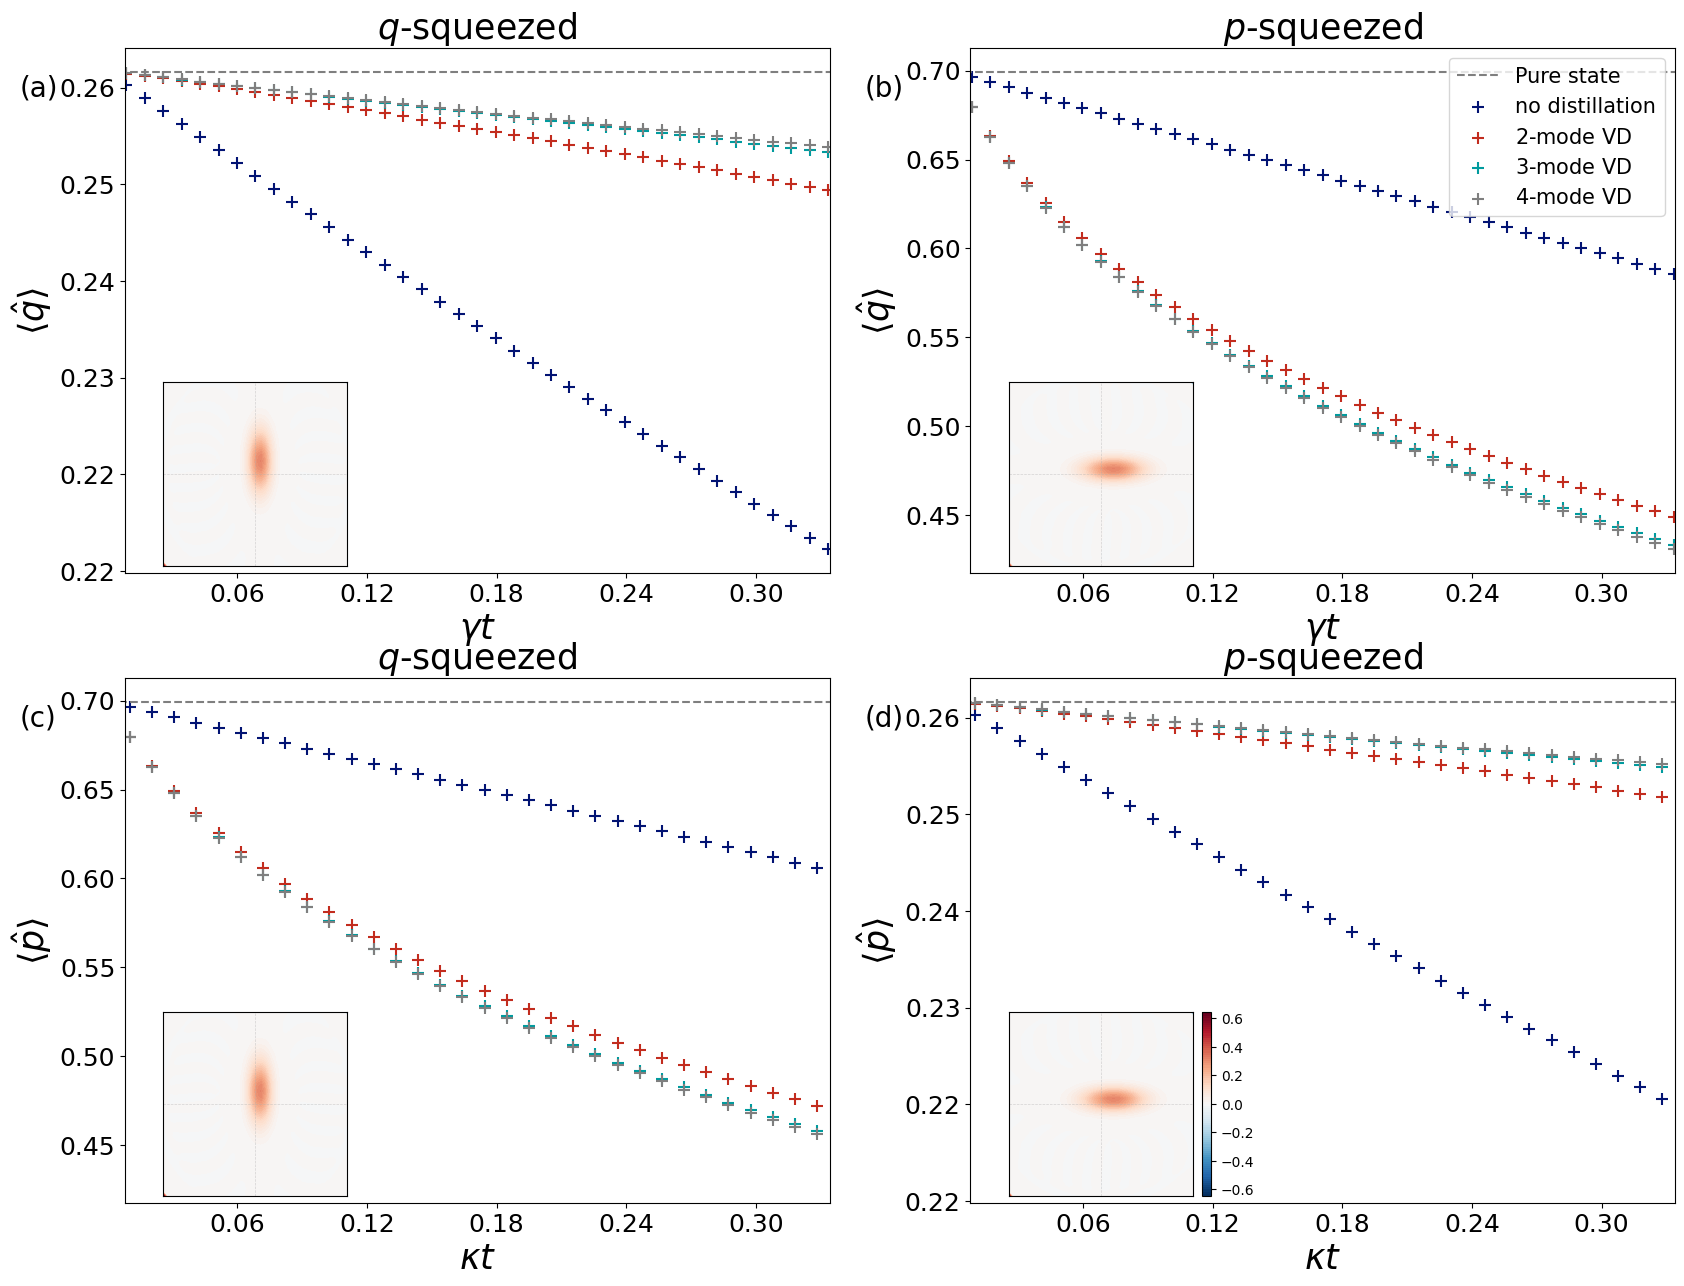

In [9]:
fig, ax = plt.subplots(2, results_l[0].shape[0], figsize=(10*results_l[0].shape[0],15))

plot_theoretical_results(fig, ax[0], results_l[0], rho_noisy_list, M_list, t_list, observable_q_label, (dephasing_rate, "gamma"),
    plot_params = {'colors': colors,
                    'show_wigner': True, 
                    'legend_loc': 'inside last',
                    'xmin': 0.008, 'xmax': 0.334,
                    'tick_list' : [-5, 0, 5],
                    'tick_params': {'axis':'both', 'which':'both','bottom':False, 'top':False,'left':False, 'right':False, 'labelbottom':False, 'labelleft':False},
                    'labels': ['(a)', '(b)'],
                    'wigner_cmap': 'RdBu_r',
                    'wigner_vmax': 2/np.pi,
                    'idx_wigner_colorbar': 2})

plot_theoretical_results(fig, ax[1], results_l[1], rho_noisy_list, M_list, t_list, observable_p_label, (decay_rate, "kappa"),
            plot_params = { 'colors': colors,
                    'show_wigner': True, 
                    'legend_loc': 'none',
                    'xmin': 0.008, 'xmax': 0.334,
                    'tick_list' : [-5, 0, 5],
                    'tick_params': {'axis':'both', 'which':'both','bottom':False, 'top':False,'left':False, 'right':False, 'labelbottom':False, 'labelleft':False},
                    'labels': ['(c)', '(d)'],
                    'wigner_cmap': 'RdBu_r',
                    'wigner_vmax': 2/np.pi,
                    'idx_wigner_colorbar': 1})

plt.savefig('plots/q_squeezed_p_squeezed.pdf') #, bbox_inches='tight')
plt.show() 

## IV. Adding noise to the protocol (M=3)

We consider Fock states with losses and number operator measurements. We add coherent noise in the beam splitters, interleaved losses and interleaved dephasing.
This requires more work, since we base the noise analysis on an actual implementation with the 3-mode Fourier interferometer. States are now matrices of size $N^3\times N^3$ and it takes some time to compute the associated quantum gates.

We also need to sample on different noise values to have error bars that make sense.

In [ ]:
### Numerical parameters ###

#N = 5 # 9 # More than 9 takes too long and less than 9 gives weird behaviors (the shift operator does not work for |3>)
N=6 #is the min for |2>

T_1 = 500 # μs
decay_rate_mean = 1/T_1 # average decay rate κ of the cavity (only for losses)
decay_rate_std = decay_rate_mean/20 # we consider a 10% variability in the decay rate, gaussian distributed

T_2 = 600 # μs
dephasing_rate_mean = 1/T_2 # average dephasing rate γ of the cavity
dephasing_rate_std = dephasing_rate/20


interleaved_time = 10 # μs time between each gate in the protocol

nb_protocol_samples = 20 # for each input we perform the protocol a few times to have the corresponding error bar

t_max = 100 # μs (such that κt ~ 0.2)
nb_t_samples = 10 # 20
t_list = np.linspace(0,t_max,nb_t_samples)

In [27]:
n = 2 # 3
rho_fock_pure = qutip.fock_dm(N, n)


# We create the list of noisy states (ON THE FULL 3-MODE SYSTEM): rho_tot_list[i][j] is the j-th sample at time t_list[i], ie a matrix of size (N^3, N^3)
# We cannot use super operators since they are too big

rho_tot_list = compute_noisy_states_losses(N, t_list, rho_fock_pure, nb_protocol_samples, decay_rate_mean, decay_rate_std, nb_copies=3, print_progress=True)

(1/10)********************(2/10)********************(3/10)********************(4/10)********************(5/10)********************(6/10)********************(7/10)********************(8/10)********************(9/10)********************(10/10)********************

In [28]:

eps_std = np.pi/4 * 2/100 # 5% of pi/4
initial_sin_angles = np.sqrt((1/2,1/2,1/3)) # exact values
noise_list = np.random.normal(0,eps_std,(nb_t_samples, nb_protocol_samples, 3))


F_list = create_F3_list(N, initial_sin_angles, noise_list, print_progress=True)

(1/10) ********************(2/10) ********************(3/10) ********************(4/10) ********************(5/10) ********************(6/10) ********************(7/10) ********************(8/10) ********************(9/10) ********************(10/10) ********************

In [29]:
# compute theoretical result for comparison 

rho_pure_list = [ (qutip.fock_dm(N, n), f'Fock state $|{n}⟩$ with errors') ] 
loss_channel_list = [loss_channel(N, decay_rate, t) for t in t_list]
rho_noisy_list = [ ([channel(rho) for channel in loss_channel_list], label) for (rho, label) in rho_pure_list]

observable = qutip.num(N)
observable_label = '$\\langle\\hat{n}\\rangle$'
M_list = [(1, 'no distillation')] + [(3, '$3$-mode VD')] #[(1, 'no distillation')] + [(M, f'${M}$-mode VD') for M in [2,3,4]]

# define the final operators for the full protocol
n1 = qutip.tensor(qutip.num(N),  qutip.identity(N), qutip.identity(N))
n2 = qutip.tensor(qutip.identity(N), qutip.num(N),  qutip.identity(N))
n3 = qutip.tensor(qutip.identity(N), qutip.identity(N), qutip.num(N))
den_op = (2j*np.pi/3*(n1+2*n2)).expm()
num_op = (n1+n2+n3)/3 * den_op


results_th = np.real_if_close(perform_protocol(N, rho_noisy_list, M_list, observable))
results_err = perform_protocol_errors(N, rho_tot_list, F_list, decay_rate_mean, decay_rate_std,
                                  dephasing_rate_mean, dephasing_rate_std, interleaved_time, [num_op, den_op], print_progression=True)
#results_err.shape

(1/10) ********************(2/10) ********************(3/10) ********************(4/10) ********************(5/10) ********************(6/10) ********************(7/10) ********************(8/10) ********************(9/10) ********************(10/10) ********************

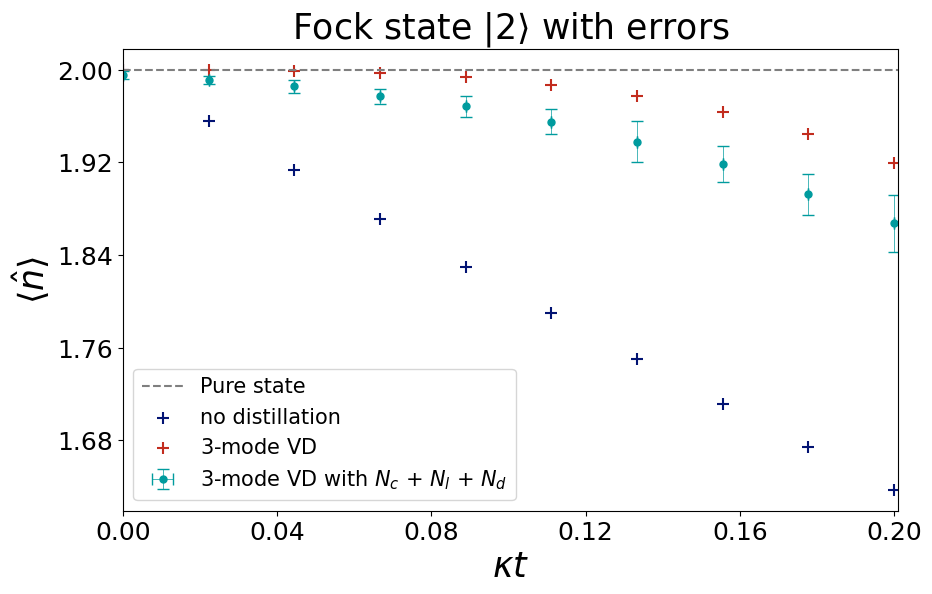

In [30]:
fig, ax = plt.subplots(1,1, figsize=(10,6))

ax.errorbar(decay_rate_mean*t_list, np.abs(results_err.mean(1)), results_err.std(1), np.zeros_like(t_list), 
                    barsabove=True, elinewidth=.5,fmt='.',
                    label="3-mode VD with $N_c$ + $N_l$ + $N_d$",
                    c=colors[4], ms=10,capsize=4)

plot_theoretical_results(fig, [ax], results_th, rho_noisy_list, M_list, t_list, observable_label, (decay_rate, "kappa"),
            plot_params = {'colors': colors, 'show_wigner': False, 'legend_loc': 'inside bottom',
                           'xmin': 0, 'xmax': 0.201, 'labels': ['']})
plt.savefig('plots/Fock_with_errors.pdf', bbox_inches='tight')
plt.show()

Work In Progress